## SBI Interactive Tutorial
---

In this interactive tutorial we demonstrate the usage of Simulation-Based Inference (or SBI).

Let's start with a few words about what SBI is and how it can be useful in many areas of natural sciences - including cosmology.

Frequently, science involves making a model with parameters, computing an output and comparing with real-life data, which is then used to adjust the model. This creates a feedback loop between experimentation or observation, and models, using inference.
The way many scientists go from data to constraints involves using Bayes' formula:

\begin{equation}
p(\theta | x) = \frac{p(x| \theta)p(\theta)}{p(x)}
\end{equation}
where $\theta$ represents the model parameters and $x$ the data. Typically, $p(\theta | x)$ is called the posterior, $p(x| \theta)$ the likelihood, $p(\theta)$ the prior and $p(x)$ the evidence.

Classical techniques such as Markov Chain Monte Carlo use evaluations of the likelihood to accept or reject proposed steps by giving weighted samples of the join posterior $p(\theta |x)$. In many cases, $\theta$ is highly dimensional. Which leads to one major problem: intractability. The problem is as you try to get the likelihoods to be more and more accurate, summary statistics start to fail.

Computing 
\begin{equation} p(x) = \int d\theta p(x | \theta) p(\theta) \end{equation} 
cannot be done numerically due to lack of resources. Sometimes even the likelihood 
\begin{equation} p(x | \theta) = \int d\eta p(x, \eta | \theta), \end{equation}
where $\eta$ are latent variables, is intractable too.

This is where models, such as Markov processes, are used to by-pass this intractability problem. Those models, also known as "classical inference" methods, often cannot evaluate the full likelihood and therefore simulations are restricted to theoretically controlled summary statistics. The second problem is the necessity to vary over instrumetal calibration parameters, foreground residuals, latent variables, etc. And sampling the joint posterior when including all these additional parameters leads exponentially increasing computational costs.

On the other hand, simulation-based inference, also known as "likelihood-free inference" or "implicit likelihood inference" uses the recent progress made thanks to machine learning algorithms to learn the probability density or a likelihood ratio. Neural networks are used to approximate one of three quantities from Bayes' formula:

- $p(\theta | x)$, through a Neural Posterior Estimation (NPE),
- $p(x | \theta)$, through a Neural Likelihood Estimation (NLE),
- $\frac{p(x | \theta)}{p(x)}$, through a Neural Ratio Estimation (NRE). 

Once trained, the network can rapidly generate posteriors for any data drawn from the distribution. 
We can do any shape of likelihood and distribution in theory. The training of these density estimation takes place on a forward simulation that contains as much of the horrible physics as one desires. It is much easier to simulate this physics rather than workout the probability of it happening given data.

This enables rapid tests of statistical consistency that are not possible with sampling-based methods. 
It is therefore possible to draw many samples from the simulation bank, generate posteriors, and see how often the true parameters lie within the N% credible region. The network's predictions are then compared to empirical coverage to assess convergence and ensure the network is not overconfident. This consistency test makes no reference to likelihoods or the true parameters of observed data.

First let's start by importing the relevant libraries needed.

In [1]:
import numpy as np
from getdist import plots, MCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sbi.inference import NLE, NPE
from sbi.utils import BoxUniform
import torch
from tqdm import tqdm

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

/opt/homebrew/Caskroom/miniconda/base/envs/sbi_tutorial/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Notebook outline

- helper functions
- simulator
- compression
- NLE
- NPE
- Sequential SBI
- coverage test
- comparison with ground truth

## SBI pipeline


          ┌──────────────┐
          │ Prior p(θ)  │
          └──────┬───────┘
                 │
                 ▼
          ┌──────────────┐
          │ Simulator   │
          └──────┬───────┘
                 │
                 ▼
          ┌──────────────┐
          │ Data x      │
          └──────┬───────┘
                 │
                 ▼
          ┌──────────────┐
          │ Neural SBI  │
          └──────┬───────┘
                 │
         ┌───────┼────────┐
         ▼       ▼        ▼

      NPE      NLE      NRE

                 │
                 ▼
            Posterior
                 ▲
                 │
      x_obs ─────┘

                 │
                 ▼
         Proposal p_r(θ)
                 │
                 ▼
       Additional simulations
                 │
                 └─────────────► (loop)


### Plotting function

To help visualise high-dimensional probability distributions, it is common to represent them in corner plots (sometimes also called triangle plots). This involves representing the 1D marginalised distributions on the diagonal and the 2D joint distributions on the off-diagonal panels.

In [2]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    with mpl.rc_context():
        # g = plots.getSubplotPlotter(width_inch=12)
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18
        if params_to_plot:
            g.triangle_plot(
                mc_samples, params=params_to_plot, filled_compare=True, normalized=True
            )
        else:
            g.triangle_plot(mc_samples, filled_compare=True, normalized=True)

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()
        
def plot_spectra(spectra):
    pass
    

## For a cosmic shear simulator, we need to first define some redshift bins

We are going to simulate some cosmic shear, that is small coherent distortions of the distant background due to massive objects in the foreground on the path of light between the background and Earth. These distortions are also known as weak gravitational lensing.

For cosmic shear surveys we put galaxies in redshift bins cause we don't know precisely what the redshift is so we put them in bins to account for this.

Here we are making use of smail distributions of widening width, defined as

$$
n(z)=z_a \exp{(z/z_0)^b}
$$

This defines for us the number density of "objects", in our case galaxies, in a given tomographic bin. 

We can think of each tomographic bin as a "shell" of observations going further away from us that we have banded together. 

We have split our mock galaxy survey into 5 tomographic bins.

In [3]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

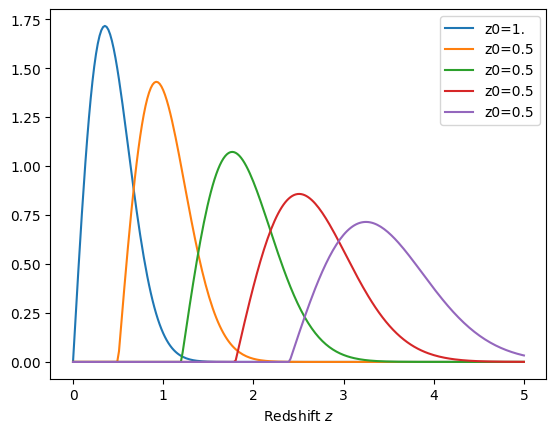

In [4]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

Weak lensing probes are a cosmological technique to constrain the distribution of matter, particularly dark matter, in the Universe.

In [5]:
probes = [jc.probes.WeakLensing(nzs, sigma_e=0.26),]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [6]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

## Let's run a cosmological simulator to calculate a lensing power spectrum with our parameter setup

In [7]:
cosmo_data = jc.Planck15()

In [8]:
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = jax.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov, key=jax.random.PRNGKey(42))

## Let's plot this all to see what our data vector looks like

So here we are plotting the auto power spectrum and cross power spectrum across all of the tomographic bins for weak lensing

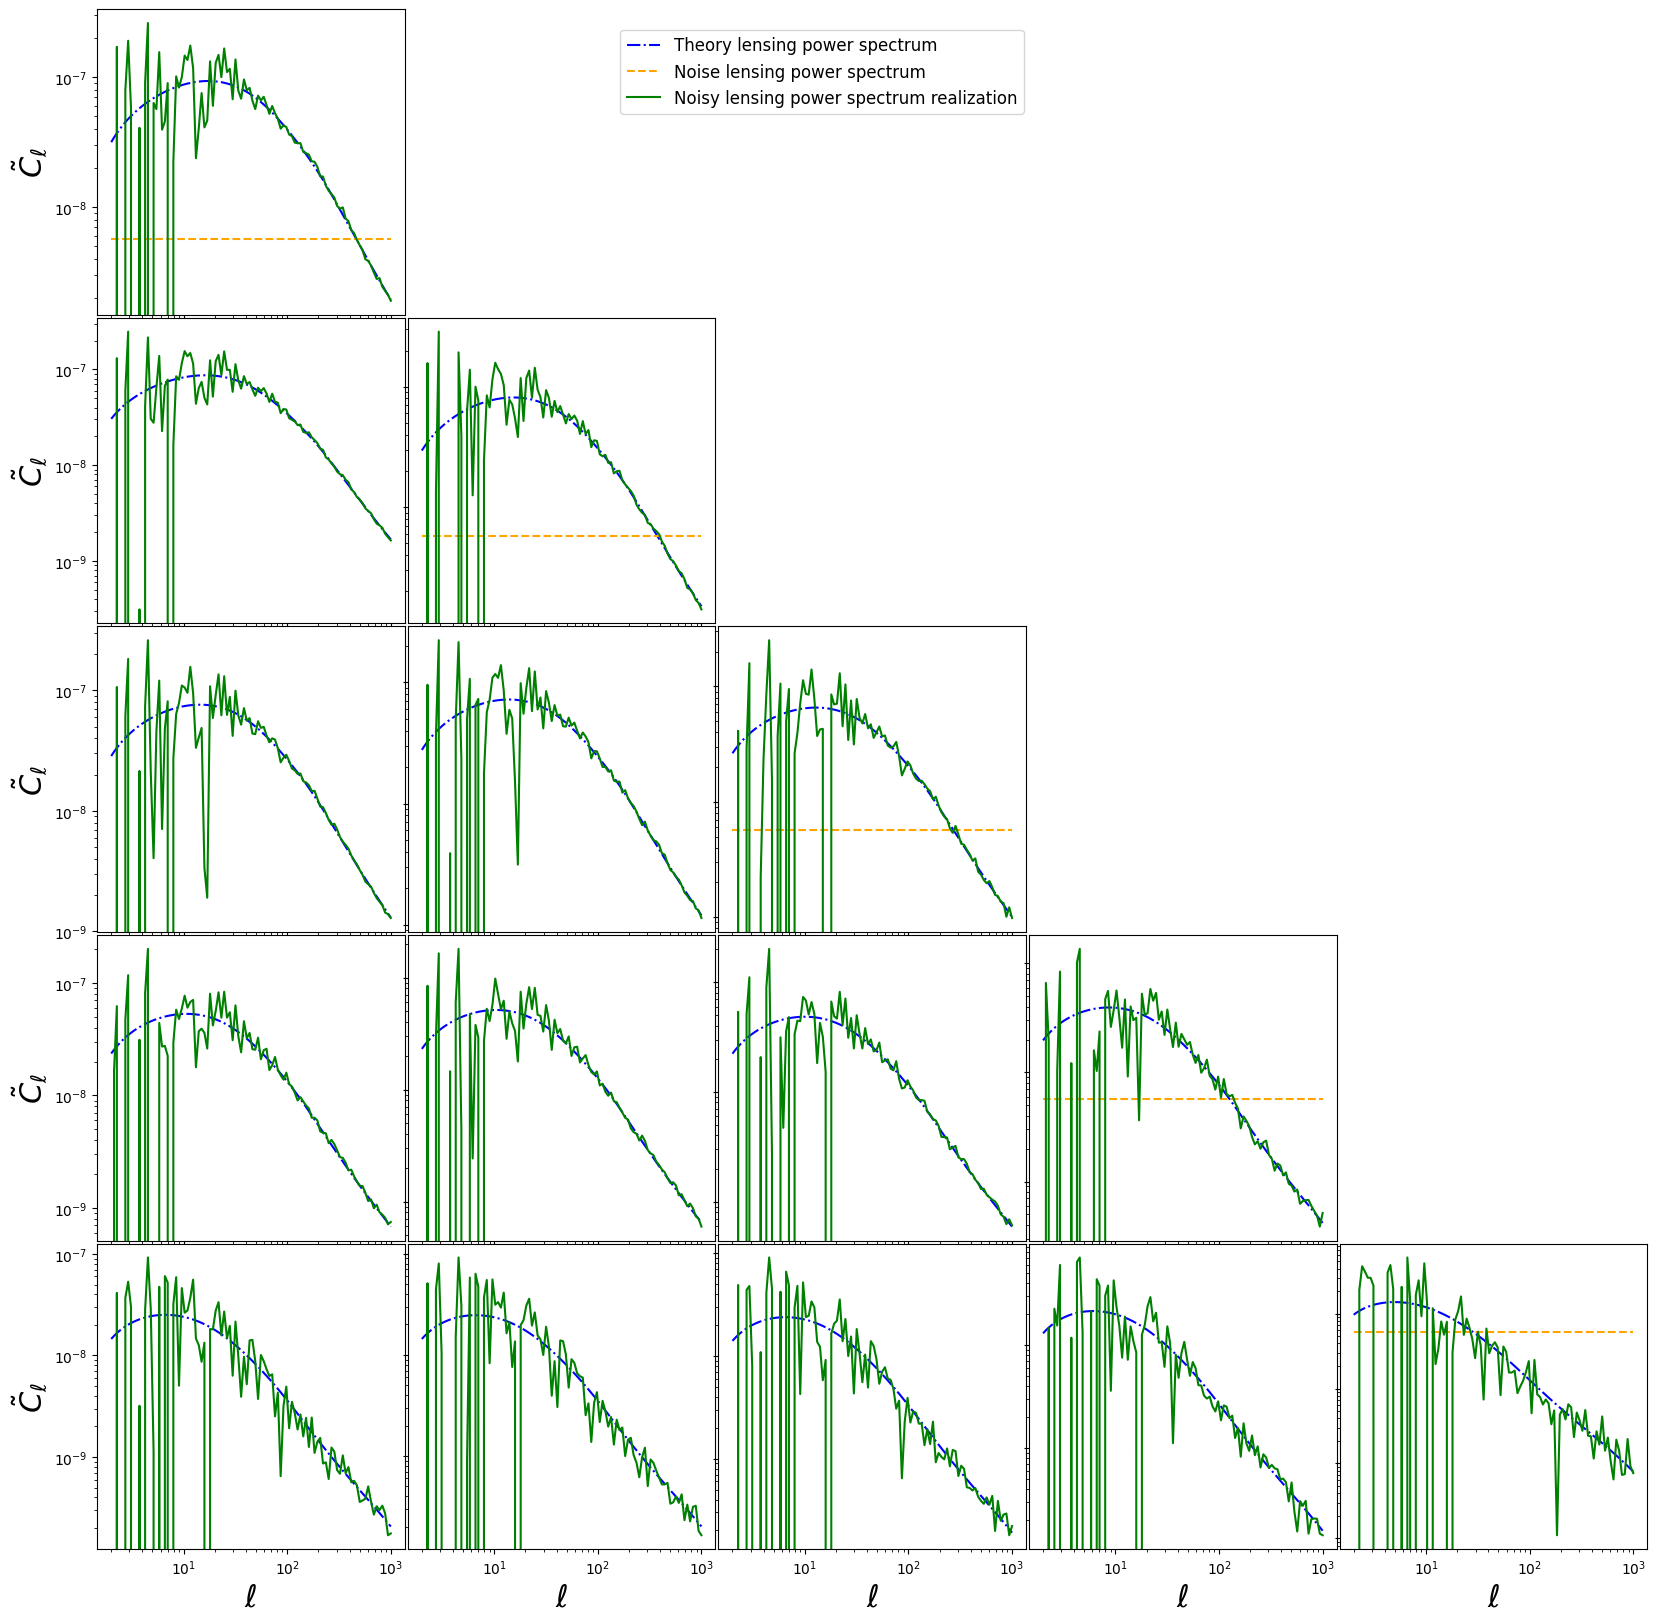

In [9]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory lensing power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise lensing power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy lensing power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

The blue -.- line corresponds to the theoretical angular power spectrum from gravitational lensing. The orange dashed line corresponds to the noise contributions to auto-spectra. The green continuous line corresponds to the noisy simulated angular power spectrum from gravitational lensing.

## Let's turn this into jax vmappable simulator for efficiency

Jax vamp is a vectorised function mapper, this means it applies a function (here single_sim) over the vectorised parameters to allow efficient parallelisation.

Instead of doing a for loop for each key the function is applied to, several computations can be ran in parallel with vectorisation. In our case we are dividing the computation into chunks of 100. This means 100 simulations are ran in parallel, this is because there is not enough compute space on a personal machine to run all simulations in parallel. The chunk size can be adapted easily to improve efficiency on clusters or bigger machines.


In [10]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [11]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in tqdm(range(n_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)
        
    return jnp.vstack(results)

## Set priors

Setting some flat priors for simplicity's sake. These are parameter priors, they can be made more complicated for more realistic results but should have limited impact in our toy example.


In [12]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)

## Let's use the same simulator to generate some simulated data with Gaussian noise


In [13]:
sim_samples_compression = prior.sample((2000,)).numpy()
simulated_data_compression = chunked_simulator(sim_samples_compression, chunk_size=10)

100%|██████████| 200/200 [00:41<00:00,  4.76it/s]


## Let's setup a compression method with CCA

Given the paired parameters and data,
$$
\begin{align}
\theta\in{\rm I\!R}^N,\;\;&\;\; X\in{\rm I\!R}^M \\
\end{align}
$$
we apply projection to both spaces.
$$
\begin{align}
\^{\theta}=U_\theta\theta\;,&\;\;\;\;U_\theta= \begin{pmatrix} w_1 & w_2 & \cdots & w_R \end{pmatrix}^T\\
\^{X}=U_XX\;,&\;\;\;\;U_X= \begin{pmatrix} v_1 & v_2 & \cdots & v_R \end{pmatrix}^T
\end{align}
$$
The vectors that form the compression matrix are solved via maximising the correlation in the projected space,
$$
w,\,v = \underset{w, v}{\operatorname{argmax}} \frac{w^{\top} \Sigma_{\theta X} v}{\sqrt{w^{\top} \Sigma_{\theta} w} \sqrt{v^{\top} \Sigma_{X} v}}
$$
where $\Sigma_{\theta X}$ is the cross covariance.
<br><br>Since we are seeking to compress the data vector $X$, we only need to find $v_1,...,v_R$. 

It would turn out that $R=min(N,M)$ due to the nature of the eigenvalue problem being solved when maximising the correlation.
$$
\Sigma_X^{-1}\Sigma_{X\theta}\Sigma_\theta^{-1}\Sigma_{\theta X} v = \lambda v
$$

In [14]:
n_params = sim_samples_compression.shape[1]

cca_cov = np.cov(sim_samples_compression.T, simulated_data_compression.T)
cp = cca_cov[:n_params,:n_params]
cd = cca_cov[n_params:,n_params:]
cpd = cca_cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerically stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector)) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

## Now let's make a mock data vector with our simulator and compress it

In [15]:
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]

In [16]:
mock_theta = torch.tensor([truth], dtype=torch.float32)
mock_obs = chunked_simulator(mock_theta.numpy(), chunk_size=1)[0]
compressed_obs = torch.as_tensor(np.asarray(mock_obs@evecs).copy(), dtype=torch.float32)

100%|██████████| 1/1 [00:02<00:00,  2.56s/it]


## Now let's do some SBI with NLE
An overview of the NLE method is as follows:
1. Define prior $\pi(\theta)$
2. Introduce proposal likelihood $q_\phi(x|\theta)$ represented by a conditional normalising flow network.
3. Obtain training data $(x,\theta)$ using $\theta\sim \pi(\theta)$
4. Train $q_\phi(x|\theta)$ to approximate the true likelihood $p(x|\theta)$ with respect to the loss. $D_{KL}(\,p(x|\theta)\,||\,q_\phi(x|\theta)\,)$.
5. For sequential, repeat steps 3 and 4 but change the distribution we draw simulations from 

Here are some references:
1. Sequential neural likelihood: Fast likelihood-free inference with autoregressive flows (Papamarkaios, Sterratt & Murray 2019)
2. Fast likelihood-free cosmology with neural density estimators and active learning (Alsing, Feeney, Charnock, Wandelt 2019)
3. Flexible and efficient simulation-based inference for models of decision-making (Boelts, Lueckmann, Gao, Macke 2022)
4. KiDS-SBI: Simulation-based inference analysis of KiDS-1000 cosmic shear (von Wietersheim-Kramsta, Lin, Tessore, Joachimi, Loureiro, Reischke, Wright 2024)

In [19]:
num_sims=5000
nle_inference = NLE(prior)

In [20]:
theta = prior.sample((num_sims,))
x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
_ = nle_inference.append_simulations(theta, compressed_x).train()
nle_posterior = nle_inference.build_posterior().set_default_x(compressed_obs)

100%|██████████| 500/500 [01:56<00:00,  4.29it/s]


 Neural network successfully converged after 77 epochs.

/opt/homebrew/Caskroom/miniconda/base/envs/sbi_tutorial/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


NLE learns the likelihood q(x|θ)so we still need MCMC to get a posterior, which is why an MCMC is automatically ran at the end of the previous ccell.

NPE learns the posterior q(θ|x)directly. This means one no longer requires sampling to obtain the posterior, and therefore avoids the process of running an MCMC altogether.

## Get some posterior samples with emcee


In [21]:
nle_posterior_theta = nle_posterior.sample((20000,), x=compressed_obs, num_chains=100)

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

## Let's also calculate the log probs for these samples

In [22]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/var/folders/_g/hxddz349657dszdwtj_sxwr40000gp/T/ipykernel_51977/3446126637.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Let's also do the same thing with NPE

An overview of the NPE method is as follows:
1. Define prior $\pi(\theta)$
2. Introduce proposal distribution $q_\phi(x|\theta)$ represented by a conditional normalising flow network.
3. Obtain training data $(x,\theta)$ using $\theta\sim \pi(\theta)$
4. Train $q_\phi(x|\theta)$ to approximate the true posterior $p(\theta|x)$ with respect to the loss. $D_{KL}(\,p(\theta|x)\,||\,q_\phi(\theta|x)\,)$.
5. For sequential, repeat steps 3 and 4 but change the distribution we draw simulations from 

Here are some references:
1. Fast ε-free Inference of Simulation Models with Bayesian Conditional Density Estimation by Papamakarios & Murray (NeurIPS 2016)
2. Flexible statistical inference for mechanistic models of neural dynamics by Lueckmann, Goncalves, Bassetto, Öcal, Nonnenmacher & Macke (NeurIPS 2017)
3. Automatic posterior transformation for likelihood-free inference by Greenberg, Nonnenmacher & Macke (ICML 2019)
4. BayesFlow: Learning complex stochastic models with invertible neural networks by Radev, S. T., Mertens, U. K., Voss, A., Ardizzone, L., & Köthe, U. (IEEE transactions on neural networks and learning systems 2020)
5. Truncated proposals for scalable and hassle-free simulation-based inference by Deistler, Goncalves & Macke (NeurIPS 2022)
6. Flow matching for scalable simulation-based inference by Dax, M., Wildberger, J., Buchholz, S., Green, S. R., Macke, J. H., & Schölkopf, B. (NeurIPS, 2023)
7. Compositional Score Modeling for Simulation-Based Inference by Geffner, T., Papamakarios, G., & Mnih, A. (ICML 2023)

In [23]:
npe_inference = NPE(prior)

In [24]:
theta = prior.sample((num_sims,))
x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
_ = npe_inference.append_simulations(theta, compressed_x, proposal=prior).train()
npe_posterior = npe_inference.build_posterior().set_default_x(compressed_obs)

100%|██████████| 500/500 [01:31<00:00,  5.45it/s]


 Neural network successfully converged after 62 epochs.

In [25]:
npe_posterior_theta = npe_posterior.sample((20000,), x=compressed_obs)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [26]:
npe_posterior_samples = npe_posterior_theta.detach().numpy()
npe_posterior_log_probs = npe_posterior.potential(npe_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/var/folders/_g/hxddz349657dszdwtj_sxwr40000gp/T/ipykernel_51977/3451352399.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  npe_posterior_log_probs = npe_posterior.potential(npe_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


Here we have implemented amortised SBI, which means the neural network is trained over the entire prior. Training is thus quite long, but this means the surrogate model generates likelihood samples for any new observed data instantly, without needing additional simulations or retraining. This is ideal when there are several (usually more than 10) observations done.

Alternatively, it is possible to implement sequential SBI, where the process of training the network is decoupled by iteratively refining simulations in multiple rounds centred around one observation. It requires far fewer simulations to train, but the resulting likelihood is not amortised: if a new observation arrives, we must discard or heavily adapt the trained estimator and run a costly new round of inference from scratch. Sequential SBI is thus ideal when there are very few (one or less than 10) observations done.

Sequential SBI intentionally discards the global prior after the first round. It sequentially refines its simulations around a single, specific target observation $(x_{obs})$, using the previous round’s posterior as a "proposal distribution".

## Sequential SBI

Let's compare with the code to run sequential SBI for NLE

══════════════════════════════════════════════════════
 AMORTIZED SBI
══════════════════════════════════════════════════════

      Train once on many simulations
                     │
                     ▼
          x_obs ─────┼────► Posterior
                     │
          Reuse for any future x_obs



══════════════════════════════════════════════════════
 SEQUENTIAL SBI
══════════════════════════════════════════════════════

                    x_obs
                      │
                      ▼
                 Posterior
                      │
                      ▼
            Proposal distribution
                      │
                      ▼
               New θ samples
                      │
                      ▼
                 Simulator
                      │
                      ▼
                  New {(θ,x)}
                      │
                      ▼
               Retrain estimator
                      │
                      └───────────────┐
                                      │
                                      ▼
                                  Posterior
``

In [3]:
num_sims_seq = 100
num_rounds_seq = 5
nle_inference_seq = NLE(prior)
nle_proposal_seq = prior

NameError: name 'NLE' is not defined

In [ ]:
for _ in range(num_rounds_seq):
    theta_seq = nle_proposal_seq.sample((num_sims_seq,))
    x = chunked_simulator(theta_seq.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = nle_inference_seq.append_simulations(theta_seq, compressed_x).train()
    nle_posterior_seq = nle_inference_seq.build_posterior().set_default_x(compressed_obs)
    nle_proposal_seq = nle_posterior_seq

100%|██████████| 10/10 [00:00<00:00, 612.90it/s]


 Neural network successfully converged after 137 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5100 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1096.23it/s]


...

 Neural network successfully converged after 21 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5100 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 5120.00it/s]


 Neural network successfully converged after 21 epochs.

In [ ]:
nle_posterior_theta_seq = nle_posterior_seq.sample((20000,), x=compressed_obs, num_chains=100)
nle_posterior_samples_seq = nle_posterior_theta_seq.detach().numpy()
nle_posterior_log_probs_seq = nle_posterior_seq.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

/var/folders/_g/hxddz349657dszdwtj_sxwr40000gp/T/ipykernel_51977/3298625681.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nle_posterior_log_probs_seq = nle_posterior_seq.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


Now for NPE

In [ ]:
npe_inference_seq = NPE(prior)
npe_proposal_seq = prior

In [ ]:
for _ in range(num_rounds_seq):
    theta_seq = npe_proposal_seq.sample((num_sims_seq,))
    x = chunked_simulator(theta_seq.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = npe_inference_seq.append_simulations(theta_seq, compressed_x, npe_proposal_seq).train()
    npe_posterior_seq = npe_inference_seq.build_posterior().set_default_x(compressed_obs)
    npe_proposal_seq = npe_posterior_seq

100%|██████████| 10/10 [00:00<00:00, 3470.96it/s]


 Neural network successfully converged after 253 epochs.

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 3728.27it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 28 epochs.

...

100%|██████████| 10/10 [00:00<00:00, 3795.06it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 40 epochs.

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 5120.63it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 23 epochs.

In [ ]:
npe_posterior_theta_seq = npe_posterior_seq.sample((20000,), x=compressed_obs)
npe_posterior_samples_seq = npe_posterior_theta_seq.detach().numpy()
npe_posterior_log_probs_seq = npe_posterior_seq.potential(npe_posterior_theta_seq.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

  0%|          | 0/20000 [00:00<?, ?it/s]

/var/folders/_g/hxddz349657dszdwtj_sxwr40000gp/T/ipykernel_51977/3200376991.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  npe_posterior_log_probs_seq = npe_posterior_seq.potential(npe_posterior_theta_seq.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Plot!


In [33]:
param_labels = [r'\sigma_8', r'\Omega_c', r'\Omega_b', r'h', r'n_s']
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]
truth_marker = dict(zip(params, truth))

### Make the getdist MC objects

In [34]:
nle_samples = MCSamples(
    samples=nle_posterior_samples,
    loglikes=nle_posterior_log_probs,
    names=params,
    labels=param_labels,
    label="NLE Amortised SBI",
    sampler="mcmc",
)

npe_samples = MCSamples(
    samples=npe_posterior_samples,
    loglikes=npe_posterior_log_probs,
    names=params,
    labels=param_labels,
    label="NPE Amortised SBI",
    sampler="mcmc",
)

Removed no burn in
Removed no burn in


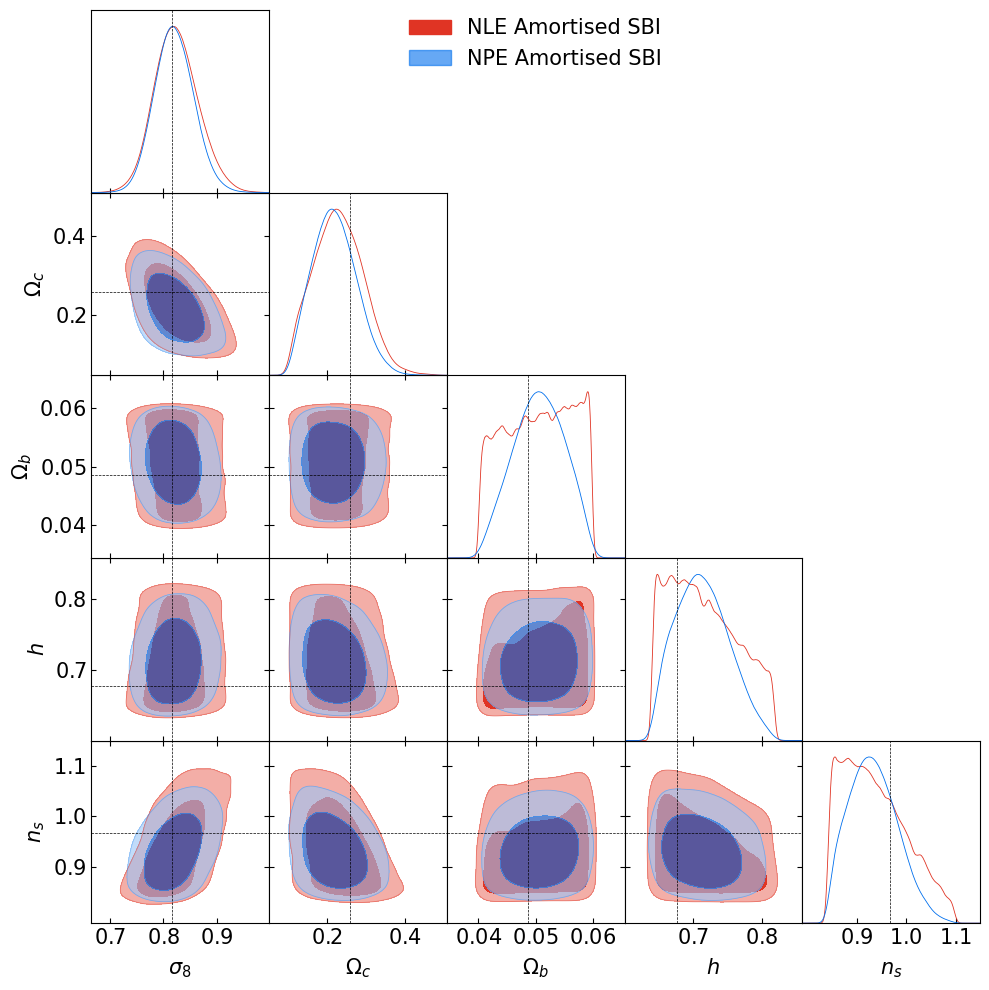

In [35]:
triangle_plot(
    [nle_samples, npe_samples],
    truth=truth_marker)

## If we now look at the results from Sequential SBI

In [36]:
nle_samples_seq = MCSamples(
    samples=nle_posterior_samples_seq,
    loglikes=nle_posterior_log_probs_seq,
    names=params,
    labels=param_labels,
    label="NLE Sequential SBI",
    sampler="mcmc",
)

npe_samples_seq = MCSamples(
    samples=npe_posterior_samples_seq,
    loglikes=npe_posterior_log_probs_seq,
    names=params,
    labels=param_labels,
    label="NPE Sequential SBI",
    sampler="mcmc",
)

Removed no burn in
Removed no burn in


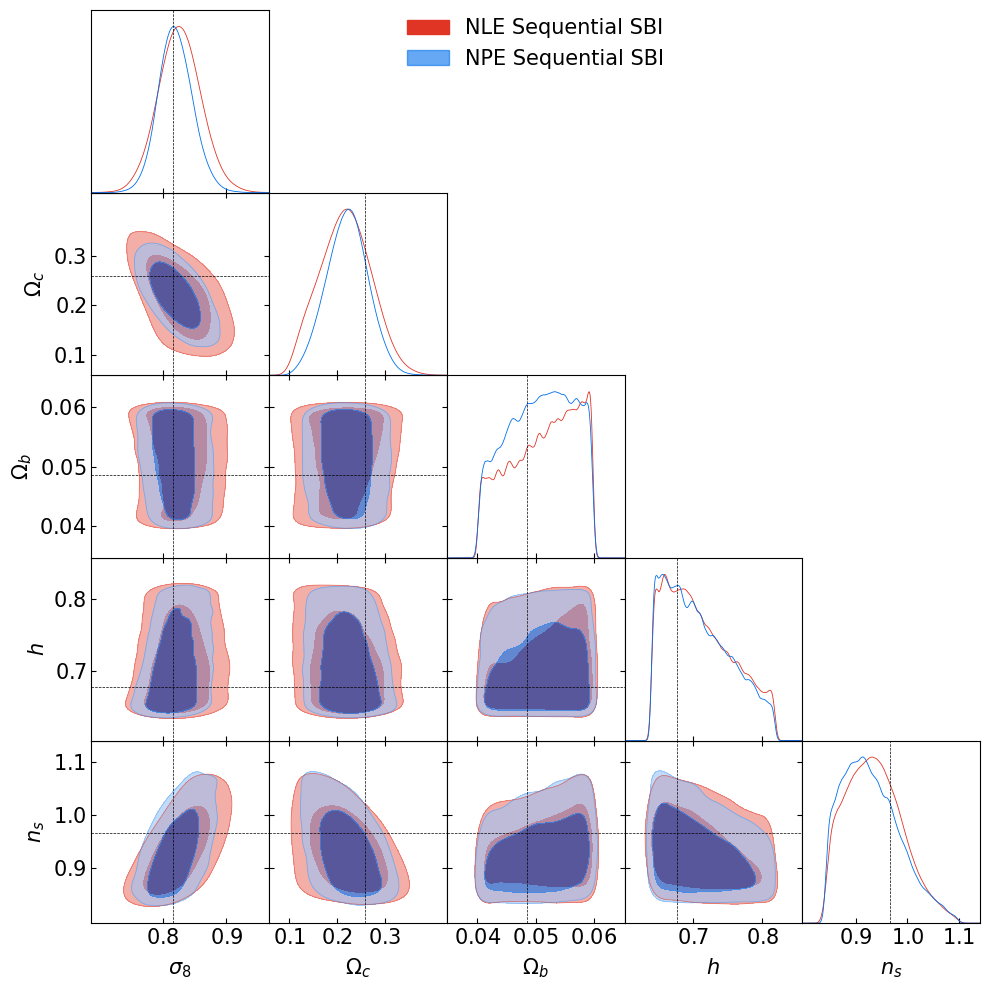

In [37]:
triangle_plot(
    [nle_samples_seq, npe_samples_seq],
    truth=truth_marker)

## So whilst we have a posterior, we should do a coverage test

We will make use of the Tests of Accuracy with Random Points (TARP) method that calculates the coverage from samples.

This test checks wether the coverage probability matches to a given credibility interval.
In the practical context of SBI, it checks whether the neural surrogate likelihood or posterior is well trained across the prior volume.

Coverage tests in general, whether TARP or otherwise, evaluate how well the inferred parameters capture the true values. This validation is crucial for ensuring the reliability of the inference results. The actual parameter values are compared against the estimated intervals and ideally, the true values should fall within. the estimated intervals a specified percentage of the time (for example, 95% confidence level).

TARP only works for amortised SBI as the posterior for sequential SBI is localised, thus testing it globally the way TARP is designed to do makes no sense. For a sequential model, you would theoretically have to restart the entire multi-round sequential training loop from scratch for every single one of the thousands of calibration data points $(x_{i})$ needed by TARP. This renders empirical calibration diagnostics completely unfeasible in practice.

References:
1. TARP by Lemos, Coogan, Hezaveh & Perreault-Levasseur (ICML 2023)
2. Simulation-Based Inference: A Practical Guide, Michael Deistler et al.

In [38]:
from sbi.diagnostics import run_tarp, check_tarp
from sbi.analysis.plot import plot_tarp

100%|██████████| 20/20 [00:01<00:00, 11.74it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/sbi_tutorial/lib/python3.12/site-packages/sbi/diagnostics/tarp.py:75: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [19:48<00:00,  5.94s/it]

0.24099987745285034 Should be close to 0
0.9999999953860058 Should be larger than 0.05


(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Credibility Level $\\alpha$', ylabel='Expected Coverage Probability'>)

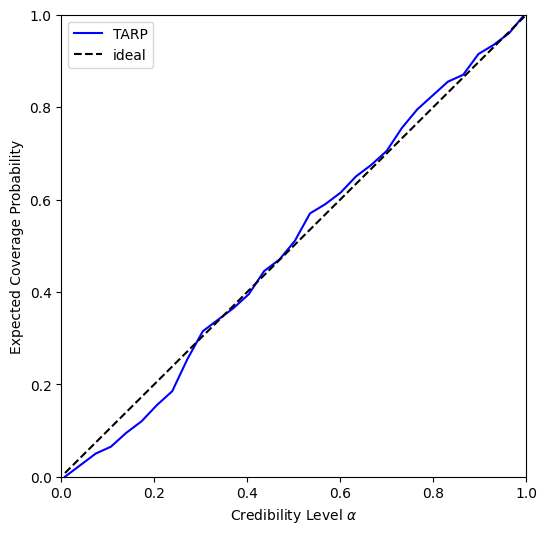

In [39]:
num_tarp_samples = 200  # choose a number of sbc runs, should be ~100s
# generate ground truth parameters and corresponding simulated observations for SBC.
tarp_samples = prior.sample((num_tarp_samples,))
prior_predictives = chunked_simulator(tarp_samples.detach().numpy(), chunk_size=10)
compressed_predictives = np.asarray(prior_predictives) @ evecs  # This is the step where we apply the compression from above to our simulated data
compressed_predictives = torch.tensor(compressed_predictives, dtype=torch.float32)

# the tarp method returns the ECP values for a given set of alpha coverage levels.
ecp, alpha = run_tarp(
    tarp_samples,
    compressed_predictives,
    nle_posterior,
    references=None,  # will be calculated automatically.
    num_posterior_samples=1000,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
# Similar to SBC, we can check then check whether the distribution of ecp is close to
# that of alpha.
atc, ks_pval = check_tarp(ecp, alpha)
print(atc, "Should be close to 0")
print(ks_pval, "Should be larger than 0.05")

plot_tarp(ecp, alpha)

In this specific case, the simulator is an explicit Gaussian. We can therefore compare the simulator against the ground truth

First let's write a simple Gaussian likelihood sampling

In [40]:
from nautilus import Prior, Sampler
from scipy.stats import multivariate_normal

""" 
As a reminder this is how are priors were defined


params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)
"""

params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']
lower = np.array([0.5, 0.1, 0.04, 0.64, 0.84])
upper = np.array([1.2, 0.5, 0.06, 0.82, 1.10])
prior = Prior()
for name, lo, hi in zip(params, lower, upper):    
    prior.add_parameter(name, dist=(lo, hi))

# Let's repeat some parameters to remind ourselves of the ground truth

cosmo_data = jc.Planck15()

truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]

nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

probes = [jc.probes.WeakLensing(nzs, sigma_e=0.26),]
ell = np.logspace(np.log10(2), np.log10(1000), 100)
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(
    ell,
    probes,
    cls,
    noise_cls,
    sparse=False)

# Let's now compute some key elements for our Gaussian likelihood

param_cov = np.diag([    
    0.05**2,    
    0.02**2,    
    0.002**2,    
    0.02**2,    
    0.03**2,])
Cinv = np.linalg.inv(param_cov)
logdet = np.linalg.slogdet(param_cov)[1]

truth = jnp.array(truth)
Cinv = jnp.array(Cinv)

norm_const = (
    -0.5 * logdet
    -0.5 * len(truth) * jnp.log(2 * jnp.pi)
)

def loglike_single(theta):
    delta = theta - truth
    return -0.5 * delta @ Cinv @ delta + norm_const



def loglike_batch(thetas):
    delta = thetas - truth
    maha = jnp.sum((delta @ Cinv) * delta, axis=1)
    return -0.5 * maha + norm_const


# Now we can sample

loglike = jax.jit(jax.vmap(loglike_single))


key = jax.random.PRNGKey(42)

thetas = jax.random.uniform(
    key,
    shape=(10000, 5),
    minval=lower,
    maxval=upper,
)

logL = loglike_batch(thetas)


def likelihood(theta):
    # theta arrives with shape (N, 5)
    return np.asarray(loglike_batch(theta))


sampler = Sampler(
    prior,
    likelihood,
    vectorized=True,
    pass_dict=False,
    n_batch=1024,
    n_live=200,
)

sampler.run(verbose=True)

points, log_w, log_l = sampler.posterior()

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 7      | 1        | 4        | 17408    | N/A    | 10161 | +8.20    


In [41]:
nautilus_samples = MCSamples(    
    samples=points,    
    weights=np.exp(log_w),    
    names=['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s'],    
    labels=[r'\sigma_8', r'\Omega_c', r'\Omega_b', 'h', r'n_s'],
    label="Gaussian sampling of the ground truth",)

Removed no burn in


This toy example does not really need SBI as it has a tractable likelihood. This simple example however allows a simple sanity check that SBI is correct by comparing with the ground truth.

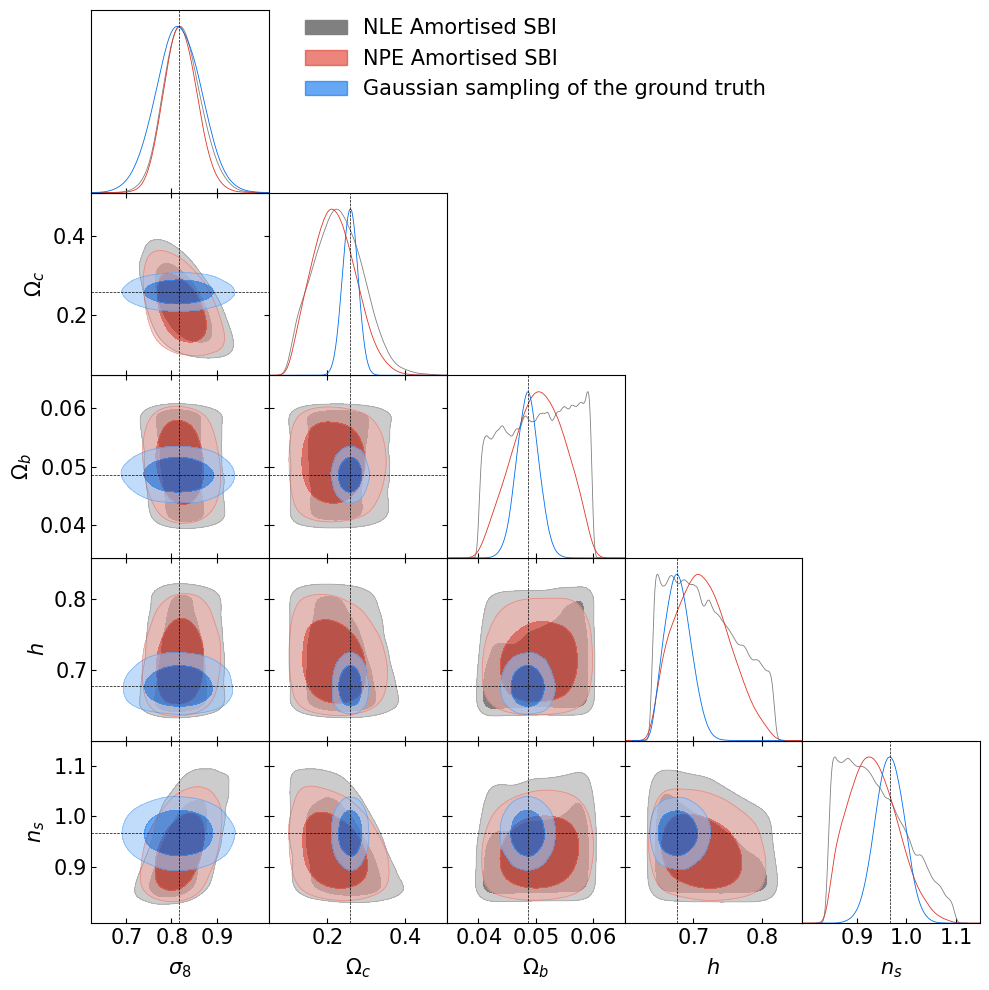

In [42]:
triangle_plot(
    [nle_samples, npe_samples, nautilus_samples],
    truth=truth_marker)

The SBI does a good job of emulating our cosmology in very little time. This is exceptionally useful when the likelihood is not tractable.

NPE has the advantage that it directly produces a posterior, whereas NLE requires an MCMC to be ran afterwards.

When it comes to sequential vs amortised SBI, generally amortised should be used and it allows for easier testing of the results. In some cases when there are very few simulations, sequential can be used, but then the default TARP cannot be used.

To test the limits of SBI and familiarise yourself with the code, the following exercises are encourage:
1. change the value num_sims to smaller values and observe the coverage degrade
2. change the compression to 3 components instead of 5 and observe the posteriors widen

Happy coding!